# Import Libraries

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import copy
import json
import os
import random
import time
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    LinearLR,
    SequentialLR,
)
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from mra_midas_skin_cancer_ml.utils.process_metadata import get_data_dir

# Global Settings

In [4]:
seed = 42

def set_seeds(seed=seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Selects best algorithm

set_seeds()

In [ ]:
INPUT_DIR = get_data_dir() / "output" / "split_images"
OUTPUT_DIR = get_data_dir() / "output" / "image_model_output"
BATCH_SIZE = 64
NUM_WORKERS = 4

# Load Model

In [6]:
def get_weights_enum(model_name):
    """Dynamically get weights enum class for a given torchvision model"""

    model_name_lower = model_name.lower()

    matches = {}
    for attr in dir(models):
        if attr.endswith("_Weights"):
            base_name = attr.replace("_Weights", "").lower()
            matches[base_name] = attr 

    if model_name_lower in matches:
        return getattr(models, matches[model_name_lower])

    raise ValueError(f"No weights enum found for model '{model_name}'")


def get_model(
    model_name,
    model_dir=Path("models"),
    device=None
):
    """
    Downloads weights if not found locally. Supports GPU if available.
    """
    
    # Modify download path from default to project folder
    model_dir = model_dir.resolve()
    os.environ["TORCH_HOME"] = str(model_dir)

    # Set device to GPU if avaliable
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    weights_enum = get_weights_enum(model_name)
    weights = weights_enum.DEFAULT

    # Define weights_path to load model if avaliable
    torch_models = {
        "resnet18": "-f37072fd",
        "resnet152": "-f82ba261",
        "inception_v3": "_google-0cc3c7bd",
        "resnext50_32x4d": "-7cdf4587",
        "resnext101_64x4d": "-173b62eb",
        "vit_b_16": "-c867db91",
        "vit_l_16": "-852ce7e3",
        "wide_resnet50_2": "-95faca4d",
    }

    weights_path = None
    if model_name in torch_models:
        filename = f"{model_name}{torch_models[model_name]}.pth"
        weights_path = model_dir / "hub" / "checkpoints" / filename

    model_constructor = getattr(models, model_name)

    if weights_path and weights_path.exists():
        print(f"\n\nLoading {model_name} weights from local path: {weights_path}")
        model = model_constructor(weights=None)
        state_dict = torch.load(weights_path, map_location=device)
        model.load_state_dict(state_dict)
    else:
        try:
            print(f"\n\nDownloading {model_name} weights from online repository.")
            model = model_constructor(weights=weights)
        except Exception as e:
            print("\n\nUnable to download weights. Returning model without weights.")
            model = model_constructor(weights=None)

    return model.to(device), weights

# Process Data

In [7]:
class ImageFolderWithPaths(ImageFolder):
    """Custom ImageFolder that returns image, label, and filename."""

    def __getitem__(self, index):
        # Get the original tuple (image, label)
        original_tuple = super().__getitem__(index)

        # Get the file path and extract filename
        full_path = self.samples[index][0]
        filename = Path(full_path).name

        # Return (image, label, filename, full_path)
        return original_tuple + (filename, full_path)


def custom_collate_fn(batch):
    """Custom collate function to handle the additional filename."""

    images, labels, filenames, full_paths = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)

    return images, labels, list(filenames), list(full_paths)

In [8]:
def get_class_weights(dataset):
    """Calculate weights for each class based on their frequency."""

    targets = [label for _, label in dataset.samples]

    class_counts = np.bincount(targets)
    min_count = np.min(class_counts)
    class_weights = min_count / class_counts
    # class_weights = 1 / class_counts

    sample_weights = [class_weights[label] for label in targets]

    print("\nClass weights:")
    for i, weight in enumerate(class_weights):
        class_name = dataset.classes[i]
        print(f"Class {class_name}: {weight:.4f}")

    return sample_weights, class_weights


def transform_load_img(input_dir, weights, use_oversampling=False):
    """Transforms and loads the train, val and test set."""

    base_transform = weights.transforms()
    print(f"Transformation: {weights.transforms()}")

    transform = {
        "train": transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),        
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            base_transform
        ]),
        "val": base_transform,
        "test": base_transform
    }

    img_train = ImageFolderWithPaths(
        Path(input_dir, "train"), transform=transform["train"]
    )
    img_val = ImageFolderWithPaths(
        Path(input_dir, "val"), transform=transform["val"]
    )
    img_test = ImageFolderWithPaths(
        Path(input_dir, "test"), transform=transform["test"]
    )

    sample_weights, class_weights = get_class_weights(img_train)

    if use_oversampling:
        print("\nUsing WeightedRandomSampler for oversampling")

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = DataLoader(
            img_train,
            sampler=sampler,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            collate_fn=custom_collate_fn,
            generator=torch.Generator().manual_seed(seed)
        )
    else:
        print("\nUsing regular DataLoader without oversampling")
        
        train_loader = DataLoader(
            img_train,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            collate_fn=custom_collate_fn,
            generator=torch.Generator().manual_seed(seed)
        )

    dataloaders = {
        "train": train_loader,
        "val": DataLoader(
            img_val,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
            collate_fn=custom_collate_fn,
            generator=torch.Generator().manual_seed(seed)
            ),
        "test":  DataLoader(
            img_test,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
            collate_fn=custom_collate_fn,
            generator=torch.Generator().manual_seed(seed)
            ),
    }

    dataset_sizes = {
        "train": len(img_train),
        "val":   len(img_val),
        "test":  len(img_test)
    }

    print(f"\nLoaded datasets from {input_dir}:")
    print(f"Train samples: {dataset_sizes['train']}")
    print(f"Validation samples: {dataset_sizes['val']}")
    print(f"Test samples: {dataset_sizes['test']}")

    class_counts = np.bincount([label for _, label in img_train.samples])
    print("\nClass distribution in training set:")
    for class_idx, count in enumerate(class_counts):
        class_name = img_train.classes[class_idx]
        print(f"Class {class_name}: {count} samples")

    return img_train, img_val, img_test, dataloaders, dataset_sizes, class_weights

# Visualize Transformation

In [9]:
%matplotlib inline

def imshow(inp, title=None):
    """Imshow for single image tensor."""

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    inp = inp.permute([1, 2, 0])
    inp = torch.clip(std * inp + mean, 0, 1)
    inp = inp.numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(inp)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


def batch_imshow(n, dataset, dataloaders, key, show_filenames=False):
    """Imshow for batch image tensor."""

    inputs, labels, filenames, full_paths = next(iter(dataloaders[key]))
    num_imgs = min(n, inputs.size(0))
    out = make_grid(inputs[:num_imgs], padding=1, nrow=3)

    class_names = dataset.classes

    if show_filenames:
        # Create subplot with space for filenames
        fig, (ax1, ax2) = plt.subplots(
            1, 
            2,
            figsize=(14, 6),
            gridspec_kw={'width_ratios': [3, 4]}
        )

        # Display images
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        out_display = out.permute([1, 2, 0])
        out_display = torch.clip(std * out_display + mean, 0, 1)
        out_display = out_display.numpy()

        ax1.imshow(out_display)
        ax1.axis("off")
        ax1.set_title("Sample Images")

        # Display filenames vertically
        filename_text = []
        for i in range(num_imgs):
            class_name = class_names[labels[i].item()]
            filename_text.append(f"{i+1}.{filenames[i]} — {class_name}")
            filename_text.append("")  # Empty line for spacing

        ax2.text(
            0.05, 
            0.95, 
            '\n'.join(filename_text),
            transform=ax2.transAxes,
            fontsize=10,
            verticalalignment='top',
            fontfamily='monospace'
        )
        ax2.axis('off')

        plt.tight_layout()
        plt.pause(0.001)
    else:
        title = [class_names[x] for x in labels[:num_imgs]]
        imshow(out, title)

# Setup Model

In [10]:
def setup_model(
    model,
    num_classes,
    dataloaders,
    lr=0.001,
    optimizer_name="sgd",
    momentum=0.9,
    weight_decay=0.0001,
    step_size=7,
    gamma=0.15,
    scheduler_name="steplr",
    use_weighted_loss=False,
    class_weights=None,
    warmup_epochs=3,
    total_epochs=40,
    T_max=None,  # For CosineAnnealingLR
    T_0=10,      # For CosineAnnealingWarmRestarts
    T_mult=2,    # For CosineAnnealingWarmRestarts
    eta_min=1e-5 # Minimum learning rate
):
    """
    Modifies the final layer of the given model to match `num_classes`,
    sets up the loss function, optimizer, and learning rate scheduler.
    """
    print(f"Number of classes: {num_classes}")
    if hasattr(model, 'heads') and isinstance(model.heads, nn.Sequential):  # ViT models
        num_feats = model.heads[-1].in_features
        model.heads[-1] = nn.Linear(in_features=num_feats, out_features=num_classes)

    elif hasattr(model, 'fc'):  # ResNet and similar
        num_feats = model.fc.in_features
        model.fc = nn.Linear(in_features=num_feats, out_features=num_classes)

    elif hasattr(model, 'classifier'):  # VGG, DenseNet
        if isinstance(model.classifier, nn.Linear):
            num_feats = model.classifier.in_features
            model.classifier = nn.Linear(in_features=num_feats, out_features=num_classes)
        else:
            num_feats = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features=num_feats, out_features=num_classes)

    elif model.__class__.__name__ == "Inception3":  # Inception v3
        if model.aux_logits:
            num_feats_aux = model.AuxLogits.fc.in_features
            model.AuxLogits.fc = nn.Linear(num_feats_aux, num_classes)
        num_feats = model.fc.in_features
        model.fc = nn.Linear(in_features=num_feats, out_features=num_classes)

    else:
        raise NotImplementedError(
            f"Unknown model architecture: {model.__class__.__name__}"
        )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if use_weighted_loss:
        if class_weights is None:
            raise ValueError("class_weights must be provided when use_weighted_loss=True")
        print("\nUsing weighted CrossEntropyLoss")
        criterion = nn.CrossEntropyLoss(
            weight=torch.FloatTensor(class_weights).to(device)
        )
    else:
        print("\nUsing regular CrossEntropyLoss")
        criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay)
    else:
        raise ValueError(
            f"Unsupported optimizer: {optimizer_name}. Choose 'adam' or 'sgd'"
        )

    if scheduler_name.lower() == "cosine":
        if T_max is None:
            T_max = total_epochs

        main_scheduler = CosineAnnealingLR(
            optimizer,
            T_max=T_max,
            eta_min=eta_min
        )

        warmup_scheduler = LinearLR(
            optimizer,
            start_factor=0.1,
            end_factor=1.0,
            total_iters=warmup_epochs
        )

        scheduler = SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, main_scheduler],
            milestones=[warmup_epochs]
        )

    elif scheduler_name.lower() == "cosine_warm_restarts":
        main_scheduler = CosineAnnealingWarmRestarts(
            optimizer,
            T_0=T_0,        # Number of epochs for first restart
            T_mult=T_mult,  # Multiplicative factor for T_0 after each restart
            eta_min=eta_min  # Minimum learning rate
        )

        warmup_scheduler = LinearLR(
            optimizer,
            start_factor=0.1,
            end_factor=1.0,
            total_iters=warmup_epochs
        )

        scheduler = SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, main_scheduler],
            milestones=[warmup_epochs]
        )

    elif scheduler_name.lower() == "plateau":
        main_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=7,
            threshold=0.01,
            threshold_mode='rel',
            verbose=True
        )

        scheduler = main_scheduler

    elif scheduler_name.lower() == "steplr":
        main_scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=step_size,
            gamma=gamma
        )

        warmup_scheduler = LinearLR(
            optimizer,
            start_factor=0.1,  # Start from 10% of the initial learning rate
            end_factor=1.0,
            total_iters=warmup_epochs
        )

        scheduler = SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, main_scheduler],
            milestones=[warmup_epochs]
        )

    else:
        raise ValueError(
            f"Unsupported scheduler: {scheduler_name}. "
            f"Choose 'plateau', 'steplr', "
            f"'cosine', or 'cosine_warm_restarts'"
        )

    return model, criterion, optimizer, scheduler

# Train Model

In [11]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, mode='max'):
        """
        Stops training if metric (e.g. accuracy or validation loss) doesn't improve
        after `patience` epochs.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

        if mode not in ['min', 'max']:
            raise ValueError(f"mode '{mode}' is not supported. Use 'min' or 'max'")
        self.mode = mode

    def __call__(self, metric):
        if self.best_score is None:
            self.best_score = metric
        else:
            if self.mode == 'min':
                # For loss: improvement happens when metric decreases
                if metric < self.best_score - self.min_delta:
                    self.best_score = metric
                    self.counter = 0
                else:
                    self.counter += 1
            else:  # mode == 'max'
                # For accuracy: improvement happens when metric increases
                if metric > self.best_score + self.min_delta:
                    self.best_score = metric
                    self.counter = 0
                else:
                    self.counter += 1

        print(f"Early stopping best score: {self.best_score:.4f}")
        print(f"Early stopping counter: {self.counter}")

        if self.counter >= self.patience:
            self.early_stop = True

In [12]:
def train_model(
    dataloaders,
    dataset_sizes,
    model,
    loss_fn,
    optimizer,
    scheduler,
    num_epochs,
    output_dir
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    hyperparams = {
        "model_architecture": model.__class__.__name__,
        "loss_fn": loss_fn.__class__.__name__,
        "optimizer": optimizer.__class__.__name__,
        "learning_rate": optimizer.param_groups[0]["lr"],
        "momentum": optimizer.param_groups[0].get("momentum"),
        "weight_decay": optimizer.param_groups[0].get("weight_decay"),
        "scheduler": scheduler.__class__.__name__,
        "step_size": getattr(scheduler, "step_size", None),
        "gamma": getattr(scheduler, "gamma", None)
    }

    if isinstance(scheduler, torch.optim.lr_scheduler.SequentialLR):
        scheduler_names = [s.__class__.__name__ for s in scheduler._schedulers]
        hyperparams["scheduler_sequence"] = scheduler_names
        if "CosineAnnealingLR" in scheduler_names:
            hyperparams["T_max"] = scheduler._schedulers[1].T_max
            hyperparams["eta_min"] = scheduler._schedulers[1].eta_min
        elif "CosineAnnealingWarmRestarts" in scheduler_names:
            hyperparams["T_0"] = scheduler._schedulers[1].T_0
            hyperparams["T_mult"] = scheduler._schedulers[1].T_mult
            hyperparams["eta_min"] = scheduler._schedulers[1].eta_min

    print("Hyperparameters:")
    for k, v in hyperparams.items():
        print(f"{k}: {v}")

    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    train_acc_history = []
    val_acc_history = []
    early_stopper = EarlyStopping()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch}/{num_epochs - 1}")
        print('-' * 10)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current learning rate: {current_lr}")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels, *_ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    if (
                        isinstance(model, torchvision.models.inception.Inception3)
                        and phase == "train"
                    ):
                        outputs, aux_outputs = model(inputs)
                        loss1 = loss_fn(outputs, labels)
                        loss2 = loss_fn(aux_outputs, labels)
                        loss = loss1 + 0.4 * loss2
                    else:
                        outputs = model(inputs)
                        if isinstance(
                            outputs, torchvision.models.inception.InceptionOutputs
                        ):
                            outputs = outputs.logits
                        loss = loss_fn(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # statistics
                preds = torch.argmax(outputs, dim=1)
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and isinstance(
                scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
            ):
                scheduler.step(epoch_loss)
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Learning rate after scheduler step: {current_lr}")
            elif phase == 'train' and not isinstance(
                scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
            ):
                scheduler.step()
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Learning rate after scheduler step: {current_lr}")

            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
            else:
                val_acc_history.append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                early_stopper(epoch_acc)

        if early_stopper.early_stop:
            print(
                f"\nEarly stopping at epoch {epoch + 1}"
                f"(no improvement in {early_stopper.patience} epochs)"
            )
            break

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val accuracy: {best_val_acc:.4f}')

    # Create save path
    sg_time = datetime.now(ZoneInfo("Asia/Singapore"))
    timestamp = sg_time.strftime("%Y%m%d_%H%M%S")
    model_name = model.__class__.__name__
    filename = f"{model_name}_{timestamp}.pt"
    save_path = output_dir / filename
    save_path.parent.mkdir(parents=True, exist_ok=True)

    # Save best model weights
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), save_path)
    model_path = save_path.resolve()
    print(f"\nBest model saved to {model_path}")

    # Save model hyperparams
    json_path = save_path.with_suffix(".json")
    with open(json_path, "w") as f:
        json.dump(hyperparams, f, indent=4)
        print(f"Hyperparameters saved to {json_path.resolve()}")

    # Plot and save train val accuracy
    history = {
        "epoch": list(range(len(train_acc_history))),
        "train_acc": train_acc_history,
        "val_acc": val_acc_history
    }

    history_path = save_path.with_name(save_path.stem + "_history.json")
    with open(history_path, "w") as f:
        json.dump(history, f, indent=4)
        print(f"Training history saved to {history_path.resolve()}")

    plt.figure()
    plt.plot(train_acc_history, label="Train Acc")
    plt.plot(val_acc_history, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plot_path = save_path.with_name(save_path.stem + "_accuracy.png")
    plt.savefig(plot_path)
    plt.close()
    print(f"Accuracy plot saved to {plot_path.resolve()}")

    return model, model_path

# Evaluate Model

In [13]:
def evaluate_and_plot(model, dataloader, class_names, checkpoint_path, output_dir):
    """Evaluate model performance on test set and plot confusion matrix."""

    set_seeds()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    all_file_names = []

    with torch.no_grad():
        for inputs, labels, file_names, _ in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.max(dim=1).values.cpu().numpy())
            all_file_names.extend(file_names)

    pred_labels = [class_names[p] for p in all_preds]
    actual_labels = [class_names[l] for l in all_labels]

    results_df = pd.DataFrame({
        "file_name": all_file_names,
        "probability_score": all_probs,
        "prediction_label": pred_labels,
        "actual_label": actual_labels
    })

    out_stem = checkpoint_path.stem
    out_dir = checkpoint_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)

    results_df.to_excel(out_dir / f"{out_stem}_predictions.xlsx", index=False)

    cm = confusion_matrix(all_labels, all_preds)
    accuracy = (cm.diagonal().sum() / cm.sum()) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
    print("\n" + report)

    out_stem = checkpoint_path.stem
    out_dir = checkpoint_path.parent
    out_dir.mkdir(parents=True, exist_ok=True)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=class_names
    )
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(out_dir / f"{out_stem}_confusion_matrix.png")
    plt.show()
    plt.close()

    with open(out_dir / f"{out_stem}_metrics.txt", "w") as f:
        f.write(f"Accuracy: {accuracy:.2f}%\n\n")
        f.write(report)

# Run Model Pipeline



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/models/hub/checkpoints/resnet18-f37072fd.pth
52.5%IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



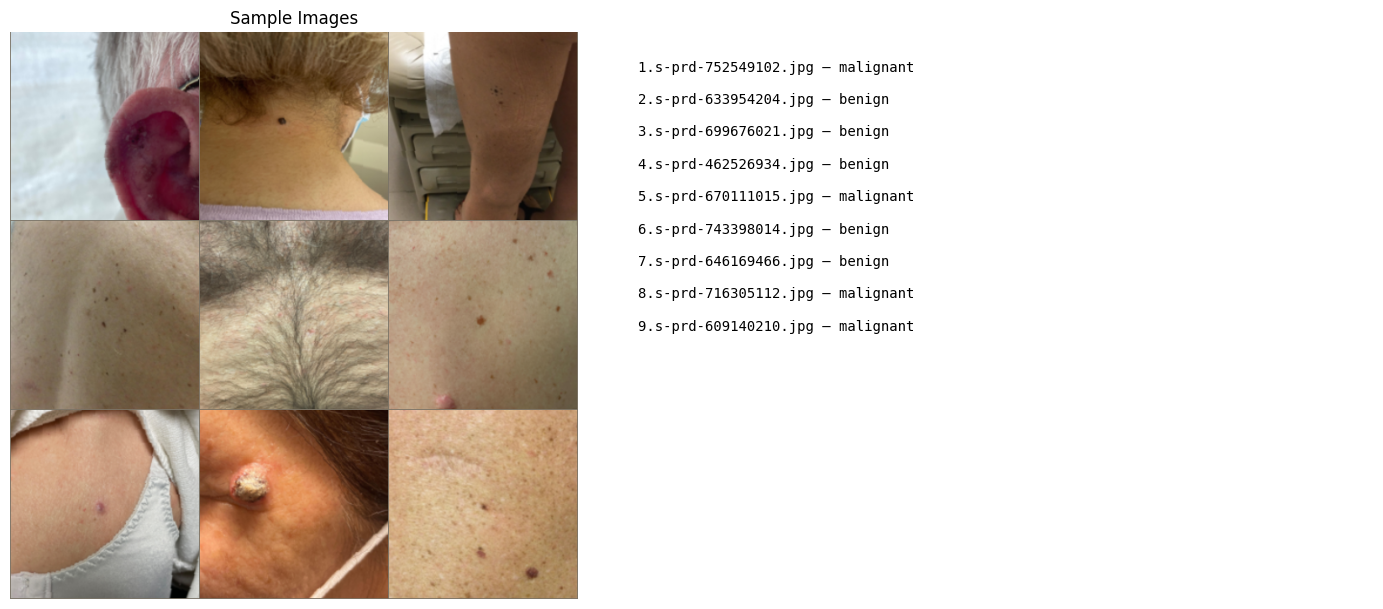

Number of classes: 2

Using regular CrossEntropyLoss
Hyperparameters:
model_architecture: ResNet
loss_fn: CrossEntropyLoss
optimizer: SGD
learning_rate: 0.0001
momentum: 0.9
weight_decay: 0.0001
scheduler: SequentialLR
step_size: None
gamma: None
scheduler_sequence: ['LinearLR', 'StepLR']

Epoch 0/29
----------
Current learning rate: 0.0001
train Loss: 0.7400 Acc: 0.4920
Learning rate after scheduler step: 0.00039999999999999996
val Loss: 0.7274 Acc: 0.4902
Early stopping best score: 0.4902
Early stopping counter: 0

Epoch 1/29
----------
Current learning rate: 0.00039999999999999996
train Loss: 0.7203 Acc: 0.5362
Learning rate after scheduler step: 0.0006999999999999999
val Loss: 0.6988 Acc: 0.5588
Early stopping best score: 0.5588
Early stopping counter: 0

Epoch 2/29
----------
Current learning rate: 0.0006999999999999999
train Loss: 0.6789 Acc: 0.5914
Learning rate after scheduler step: 0.001
/root/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning: The 

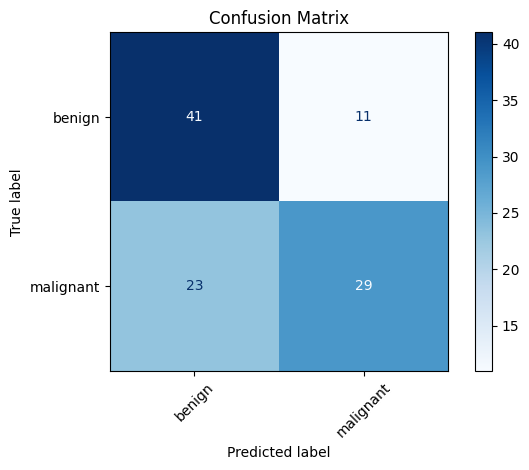



Loading resnet18 weights from local path: /tmp/models/hub/checkpoints/resnet18-f37072fd.pth
Transformation: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Class weights:
Class benign: 0.9548
Class malignant: 1.0000

Using regular DataLoader without oversampling

Loaded datasets from /tmp/mra_midas_skin_cancer_ml/data/input/split_images/6in:
Train samples: 821
Validation samples: 103
Test samples: 104

Class distribution in training set:
Class benign: 420 samples
Class malignant: 401 samples


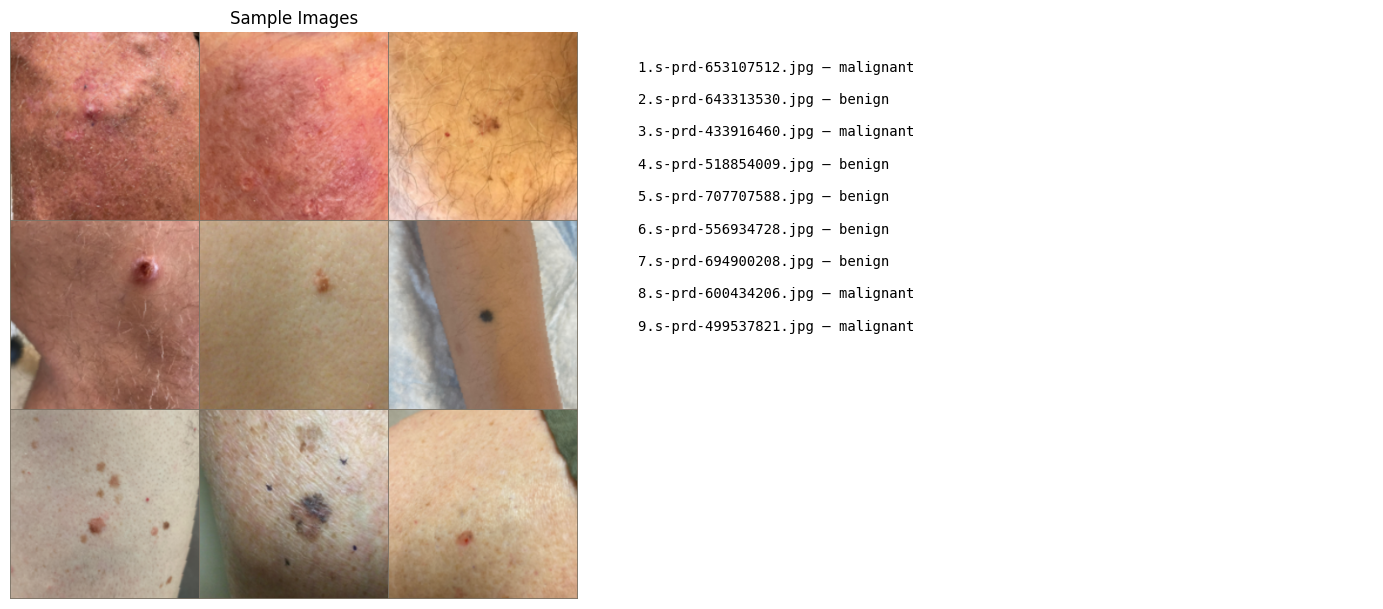

Number of classes: 2

Using regular CrossEntropyLoss
Hyperparameters:
model_architecture: ResNet
loss_fn: CrossEntropyLoss
optimizer: SGD
learning_rate: 0.0001
momentum: 0.9
weight_decay: 0.0001
scheduler: SequentialLR
step_size: None
gamma: None
scheduler_sequence: ['LinearLR', 'StepLR']

Epoch 0/29
----------
Current learning rate: 0.0001
train Loss: 0.7522 Acc: 0.4945
Learning rate after scheduler step: 0.00039999999999999996
val Loss: 0.6672 Acc: 0.6019
Early stopping best score: 0.6019
Early stopping counter: 0

Epoch 1/29
----------
Current learning rate: 0.00039999999999999996
train Loss: 0.7370 Acc: 0.5164
Learning rate after scheduler step: 0.0006999999999999999
val Loss: 0.6613 Acc: 0.6117
Early stopping best score: 0.6117
Early stopping counter: 0

Epoch 2/29
----------
Current learning rate: 0.0006999999999999999
train Loss: 0.6695 Acc: 0.6212
Learning rate after scheduler step: 0.001
/root/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning: The 

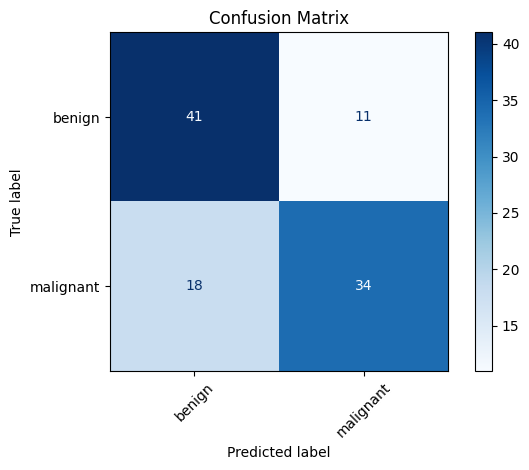



Loading resnet18 weights from local path: /tmp/models/hub/checkpoints/resnet18-f37072fd.pth
Transformation: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Class weights:
Class benign: 0.9618
Class malignant: 1.0000

Using regular DataLoader without oversampling

Loaded datasets from /tmp/mra_midas_skin_cancer_ml/data/input/split_images/dscope:
Train samples: 822
Validation samples: 103
Test samples: 103

Class distribution in training set:
Class benign: 419 samples
Class malignant: 403 samples


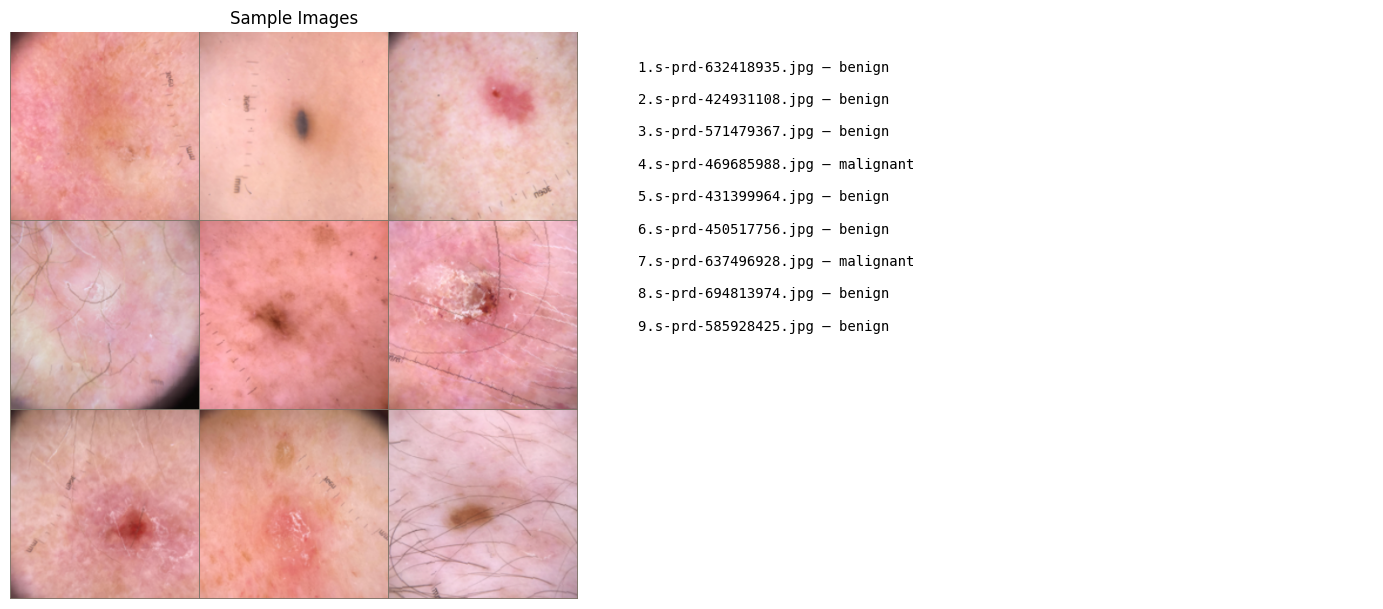

Number of classes: 2

Using regular CrossEntropyLoss
Hyperparameters:
model_architecture: ResNet
loss_fn: CrossEntropyLoss
optimizer: SGD
learning_rate: 0.0001
momentum: 0.9
weight_decay: 0.0001
scheduler: SequentialLR
step_size: None
gamma: None
scheduler_sequence: ['LinearLR', 'StepLR']

Epoch 0/29
----------
Current learning rate: 0.0001
train Loss: 0.7440 Acc: 0.4903
Learning rate after scheduler step: 0.00039999999999999996
val Loss: 0.6842 Acc: 0.5922
Early stopping best score: 0.5922
Early stopping counter: 0

Epoch 1/29
----------
Current learning rate: 0.00039999999999999996
train Loss: 0.7174 Acc: 0.5328
Learning rate after scheduler step: 0.0006999999999999999
val Loss: 0.6401 Acc: 0.6505
Early stopping best score: 0.6505
Early stopping counter: 0

Epoch 2/29
----------
Current learning rate: 0.0006999999999999999
train Loss: 0.6563 Acc: 0.6156
Learning rate after scheduler step: 0.001
/root/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning: The 

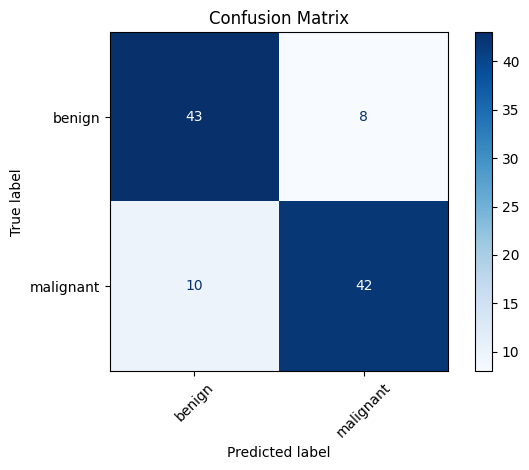

In [14]:
def run_model_pipeline(
    model_name="resnet18", 
    image_dists=["1ft","6in","dscope"], 
    visualize_transform=True
):
    # Load images
    for image_dist in image_dists:

        # Load model
        model, model_weights = get_model(model_name)        
        
        # Transform images
        train, _, _, dataloaders, dataset_sizes, class_weights = transform_load_img(
            INPUT_DIR / image_dist,
            weights=model_weights,
            use_oversampling=False,
        )

        # Visualize input images
        if visualize_transform:
            batch_imshow(9, train, dataloaders, "train", show_filenames=True)

        # Setup model 
        model, model_loss_fn, model_optimizer, model_lr_scheduler = setup_model(
            model,
            num_classes=len(dataloaders["train"].dataset.classes),
            dataloaders=dataloaders,
        )

        # Train model
        trained_model, trained_model_path = train_model(
            dataloaders,
            dataset_sizes,
            model,
            model_loss_fn,
            model_optimizer,
            model_lr_scheduler,
            num_epochs=30,
            output_dir=OUTPUT_DIR / f"{image_dist}",
        )

        # Evaluate model
        evaluate_and_plot(
            trained_model,
            dataloaders["test"],
            class_names=dataloaders["test"].dataset.classes,
            checkpoint_path=trained_model_path,
            output_dir=OUTPUT_DIR / f"{image_dist}"
        )


run_model_pipeline(visualize_transform=True)